In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Train-Test Split and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input


In [3]:
# Load training and testing datasets
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

# Display first 5 rows
print(train_df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [4]:
# First column = label
y_train = train_df.iloc[:, 0]
X_train = train_df.iloc[:, 1:]

y_test = test_df.iloc[:, 0]
X_test = test_df.iloc[:, 1:]

In [5]:
# Pixel values range from 0-255
# Convert them into 0-1 range

X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
# CNN expects image format:
# (samples, height, width, channels)

X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

In [7]:
# Convert labels into categorical format

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [9]:
model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7953 - loss: 0.5636 - val_accuracy: 0.8540 - val_loss: 0.3969
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8694 - loss: 0.3647 - val_accuracy: 0.8830 - val_loss: 0.3221
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8867 - loss: 0.3142 - val_accuracy: 0.8958 - val_loss: 0.2861
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8963 - loss: 0.2852 - val_accuracy: 0.9015 - val_loss: 0.2770
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9039 - loss: 0.2594 - val_accuracy: 0.9057 - val_loss: 0.2602


In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9081 - loss: 0.2518

Test Accuracy: 0.9081000089645386


In [13]:
y_pred = model.predict(X_test)

# Convert probabilities into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot test labels back
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [14]:
print("\nClassification Report:\n")

print(classification_report(y_true, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.91      0.80      0.85      1000
           3       0.92      0.93      0.92      1000
           4       0.81      0.91      0.86      1000
           5       0.99      0.97      0.98      1000
           6       0.73      0.74      0.74      1000
           7       0.93      0.97      0.95      1000
           8       0.97      0.99      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



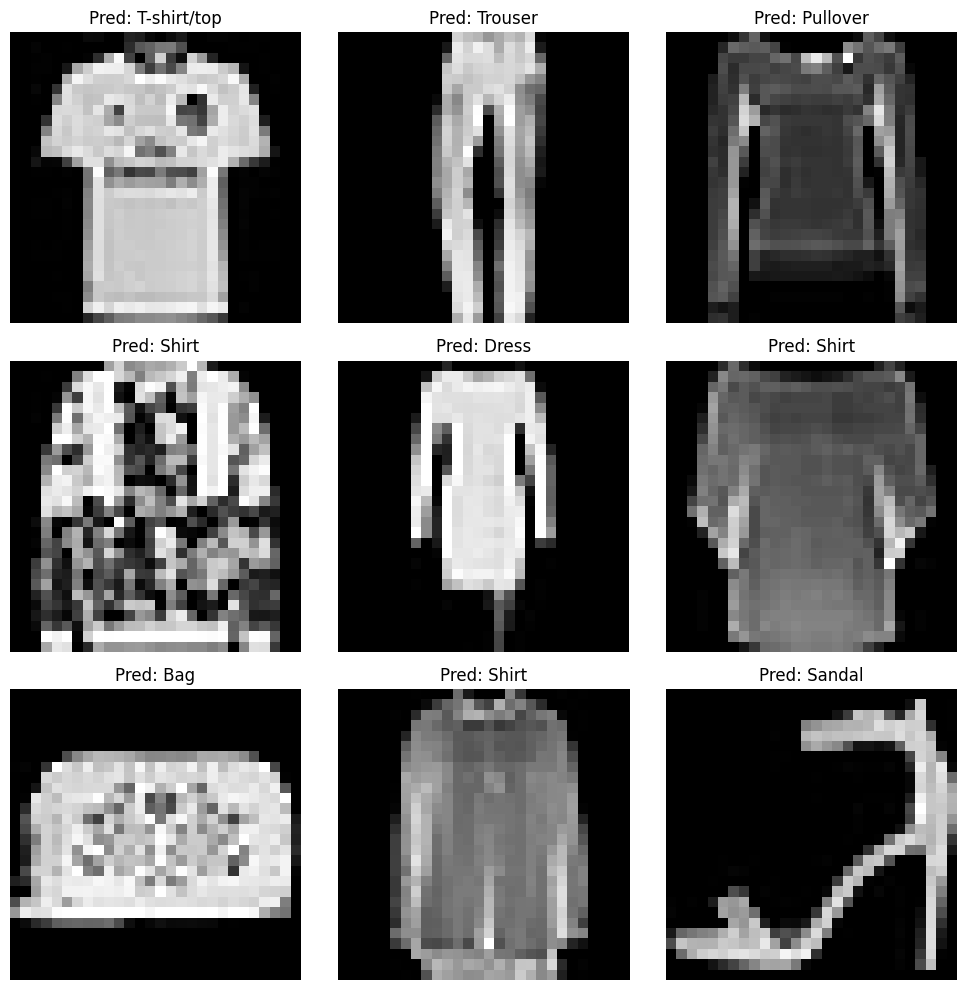

In [15]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        "Pred: " + class_names[y_pred_classes[i]]
    )

    plt.axis('off')

plt.tight_layout()
plt.show()